# INF8111 - Fouille de données
## Automne 2025 - TP2 - Analyse d'association / Association analysis
### Membres de l'équipe
    - Le Chevallier Ethan (2488083) 1
    - Gagné Cédric (2147286) 2
    - Cong Minh Dinh (2151808) 3

## Date et directives de remise

Vous devez remettre dans la boîte de remise sur moodle ce fichier nommé TP2_NumeroEquipe_matricule1_matricule2_matricule3.ipynb

**N.B**: Assurez-vous que tous les résultats soient lisibles lorsque le notebook est ouvert.

Ce notebook doit être remis avant le **15 novembre 2024 à 23h59**. Tout travail en retard sera pénalisé d’une valeur de 10\% par jour de retard.


In [1]:
# Vous pouvez installer les packages

! pip install openpyxl
! pip install mlxtend
! pip install missingno
! pip install networkx

In [2]:
# Vérifier si les librairies sont bien installées : un exemple

import networkx
print('networkx: {}'.format(networkx.__version__))

networkx: 3.5


## 0. Introduction: Analyse d'association

###  Présentation

En fouille de données, l'analyse d'association est une technique utile pour trouver des relations intéressantes dans de grands ensembles de données. Un exemple typique d'analyse d'association est l'analyse du panier de consommation(***market basket analysis***). Cette section fournit les motivations du TP pour l'utilisation de cette forme de règle d'association.

Supposons que vous êtes responsable d'un cabinet de conseil en fouille et analyse de données. Votre cabinet est contacté par un détaillant dans le but d'en savoir plus sur les habitudes d'achat de ses clients. Plus précisément, votre mission pour ce détaillant est de répondre à la question suivante :  "*_Quels groupes ou ensembles d'articles les clients sont-ils susceptibles d'acheter lors d'une visite donnée au magasin ?_* ". Pour répondre à cette question, vous décidez d'appliquer une analyse du panier de consommation à partir des données de vente mises à votre disposition par le détaillant. Les résultats pourront être utilisés pour planifier des stratégies marketing ou publicitaires, ainsi que pour la conception de catalogues. À titre d'exemple, pour une stratégie, les articles fréquemment achetés ensemble peuvent être placés à proximité les uns des autres afin d'encourager davantage la vente de tels articles ensemble. Dans une stratégie alternative, placer ces articles aux extrémités opposées du magasin peut inciter les clients qui achètent ces articles à en acheter d'autres en cours de route.


### But du TP

Le but de ce TP est de vous donner un aperçu de l'analyse des règles d'association à travers un cas pratique sur des données réelles.

Dans la première partie, vous allez préparer les données et répondre à certaines questions générales sur l'ensemble des données.

Dans la deuxième partie, vous aller générer des règles d'association premièrement avec l'algorithme a-priori et ensuite avec l'algorithme FP-growth proposé par [Jiawei Han, Jian Pei, Yiwen Yin](https://www.cs.sfu.ca/~jpei/publications/sigmod00.pdf?utm_source=chatgpt.com) que vous aurez implémenté.

### Aperçu du dataset

In [ ]:
from pathlib import Path

file_path = Path("data/tp2/retail_dataset.xlsx")
if not file_path.exists():
    file_path = Path("../../data/tp2/retail_dataset.xlsx")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Nous vous avons fourni le fichier *`retail_dataset.xlsx`* . Il contient l'ensemble des données. Chaque ligne contient les données d'une vente. La description des attributs du dataset est la suivante:

| # | Feature Name | Description |
|---|--------------|-------------|
| 1 | InvoiceNo    | Numéro de facture / Identifiant unique de chaque transaction (6 chiffres, commence par 'C' si annulation). |
| 2 | StockCode    | Code produit / Identifiant unique (5 chiffres) attribué à chaque produit distinct. |
| 3 | Description  | Nom du produit / Désignation textuelle du produit. |
| 4 | Quantity     | Quantité / Nombre d’unités du produit dans la transaction. |
| 5 | InvoiceDate  | Date de la transaction / Jour et heure où la transaction a été générée. |
| 6 | UnitPrice    | Prix unitaire / Prix du produit par unité. |
| 7 | CustomerID   | Identifiant client / Code unique (5 chiffres) attribué à chaque client. |
| 8 | Country      | Pays du client / Nom du pays de résidence du client. |



In [33]:
import pandas as pd

df= pd.read_excel(file_path)
df.head(-1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541903,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,2011-12-09 12:50:00,4.15,12680.0,France
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France


## 1.  Préparartion de données et analyse de base (25 point)

### 1.1. Valeurs manquantes

#### Question 1 (3 points )

Combien y a-t-il de valeurs manquantes ? Supprimer toutes les lignes ayant de valeurs manquantes et rassurez-vous d'avoir aucune valeur manquante après suppresion.

In [34]:
# TO DO
print("Nombre de valeurs manquantes :", df.isnull().sum().sum())
print("Taille avant suppression NA :", df.shape)

Nombre de valeurs manquantes : 136534
Taille avant suppression NA : (541909, 8)


In [35]:
df = df.dropna(how='any')

In [36]:
# En décommentant la ligne suivante, le nombre 0 devrait apparaitre à l'exécution

int(df.isnull().values.sum()) # On convertit en entier le résultat obtenu sous la forme d'un np.int64 pour plus de clarté

0

In [37]:
print("Taille après suppression NA :", df.shape)

Taille après suppression NA : (406829, 8)


Cette étape de la préparation des données est validée, on remarque qu'il n'y a plus de valeurs manquantes.

#### Question 2 (3 points)
La colonne "InvoiceNo" contient sur chaque ligne un numéro entier à 6 chiffres attribué de manière unique à chaque transaction. Si ce code commence par la lettre «C», il indique une annulation.

Supprimer maintenant les factures annulées et indiquer le nombre de lignes avant et après suppression.

In [38]:
# TO DO
# On sauvegarde le nombre de lignes avant modification
n_before = df.shape[0]

# On prépare le nettoyage en convertissant en string les valeurs de la colonne.
# On crée un masque booléen qui vérifie si chaque valeur de 'InvoiceNo' commence par un 'C' et on compte le nombre de ligne de ce masque.
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
mask_supr = df['InvoiceNo'].str.startswith('C', na=False)
n_cancel = mask_supr.sum()

# On nettoie le dataframe en ne prenant que les valeurs qui ne commencent pas par 'C'
df = df[~mask_supr].copy()
n_after = df.shape[0]

# On affiche les nombre de lignes avant/pendant/après nettoyage
print(f"Lignes avant suppression : {n_before}")
print(f"Nombre de lignes correspondant à des suppressions : {n_cancel}")
print(f"Lignes après suppression : {n_after}")

Lignes avant suppression : 406829
Nombre de lignes correspondant à des suppressions : 8905
Lignes après suppression : 397924


In [40]:
mask_verif = df['InvoiceNo'].str.startswith('C', na=False)
print(f"Nombre de lignes avec 'InvoiceNo' commençant par un 'C' : {mask_verif.sum()}")

Nombre de lignes avec 'InvoiceNo' commençant par un 'C' : 0


On valide donc cette étape.

#### Question 3 (4 points)
La description du fichier fourni par le détaillant indique que l'attribut "StockCode" est un identifiant unique à ***5 chiffres*** attribué à chaque produit distinct. Malgré cette information, le spécialiste en fouille de données que vous êtes décide de vérifier cette information.


Quelles sont les valeurs uniques de l'attribut "StockCode" dont la longueur est plus pétite que 5? Supprimer les lignes de ces valeurs et indiquer le nombre de lignes après cette suppression.

In [41]:
# TO DO
# On s'assure que StockCode est bien un string
df['StockCode'] = df['StockCode'].astype(str)

# On crée un masque pour compter toutes les lignes possédant une valeur pour l'attribut 'StockCode' dont la longueur est inférieur à 5.
len_5 = df['StockCode'].str.len() < 5

# On identifie les codes d'article unique respectant la condition précédente.
unique_short = df.loc[len_5, 'StockCode'].unique()

# On  affiche le nombre de lignes affectées.
print("Valeurs uniques de StockCode dont la longueur est < à 5 :", unique_short)
print("Nombre de lignes avec StockCode dont la longueur est < à 5 :", len_lg5 := len(df[len_5]))

# On supprime ces lignes
df = df.loc[~len_5].copy()
print("Nombre de lignes après suppression :", df.shape[0])

Valeurs uniques de StockCode dont la longueur est < à 5 : ['POST' 'C2' 'M' 'PADS' 'DOT']
Nombre de lignes avec StockCode dont la longueur est < à 5 : 1542
Nombre de lignes après suppression : 396382


In [42]:
mask_verif = df['StockCode'].str.len() < 5
print(f"Nombre de lignes avec 'StockCode' dont la longueur est < à 5 : {mask_verif.sum()}")

Nombre de lignes avec 'StockCode' dont la longueur est < à 5 : 0



### 1.2. Analyse basique
#### Questions 4 (15 points)

Pour explorer ces données, on commence par répondre à ces questions.

#### Question 4.a. (5 points)
Quels sont les 10 premiers articles les plus vendus en terme de quantité d'articles ? Indiquer les quantités correspondantes. Un histogramme est attendu.

In [46]:
top10_stock_qty = df.groupby(['StockCode', 'Description'])['Quantity'].sum().sort_values(ascending=False).head(10)
print(top10_stock_qty)

StockCode  Description                       
23843      PAPER CRAFT , LITTLE BIRDIE           80995
23166      MEDIUM CERAMIC TOP STORAGE JAR        77916
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
85099B     JUMBO BAG RED RETROSPOT               46181
85123A     WHITE HANGING HEART T-LIGHT HOLDER    36725
84879      ASSORTED COLOUR BIRD ORNAMENT         35362
21212      PACK OF 72 RETROSPOT CAKE CASES       33693
22197      POPCORN HOLDER                        30931
23084      RABBIT NIGHT LIGHT                    27202
22492      MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


On peut alors tracer l'histogramme

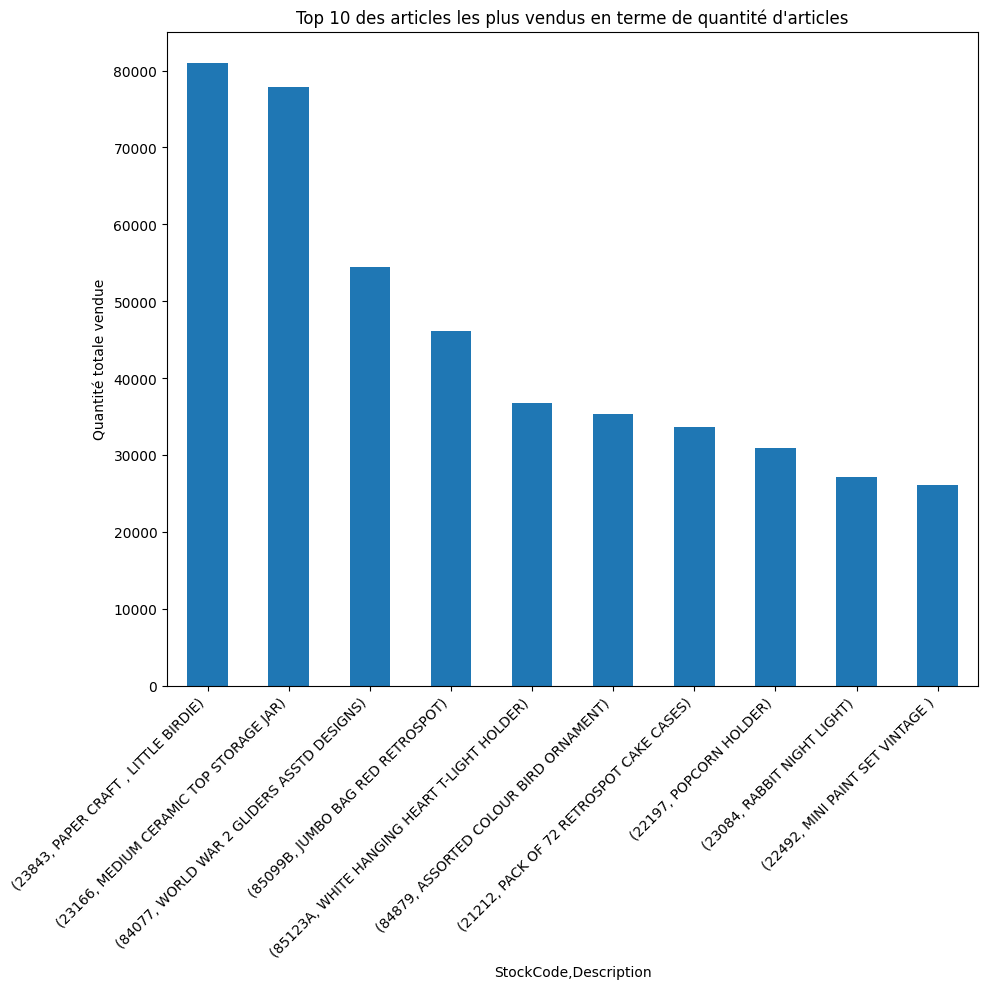

In [50]:
import matplotlib.pyplot as plt

# Histogramme des 10 premiers articles les plus vendus en terme de quantité d'articles
plt.figure(figsize=(10,10))
top10_stock_qty.plot(kind='bar')
plt.ylabel("Quantité totale vendue")
plt.title("Top 10 des articles les plus vendus en terme de quantité d'articles")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Question 4.b. (5 points)
Quels sont les 10 premiers articles les plus vendus en terme de prix ? Un histogramme est attendu.

NB : Tous les prix sont en même devise.

In [53]:
# TO DO
# On calcule d'abord le revenu total pour chaque ligne
df['Revenue'] = df['Quantity'] * df['UnitPrice']
top10_stock_revenue = df.groupby(['StockCode', 'Description'])['Revenue'].sum().sort_values(ascending=False).head(10)
print(top10_stock_revenue)

StockCode  Description                       
23843      PAPER CRAFT , LITTLE BIRDIE           168469.60
22423      REGENCY CAKESTAND 3 TIER              142592.95
85123A     WHITE HANGING HEART T-LIGHT HOLDER    100448.15
85099B     JUMBO BAG RED RETROSPOT                85220.78
23166      MEDIUM CERAMIC TOP STORAGE JAR         81416.73
47566      PARTY BUNTING                          68844.33
84879      ASSORTED COLOUR BIRD ORNAMENT          56580.34
23084      RABBIT NIGHT LIGHT                     51346.20
79321      CHILLI LIGHTS                          46286.51
22086      PAPER CHAIN KIT 50'S CHRISTMAS         42660.83
Name: Revenue, dtype: float64


On peut alors tracer l'histogramme

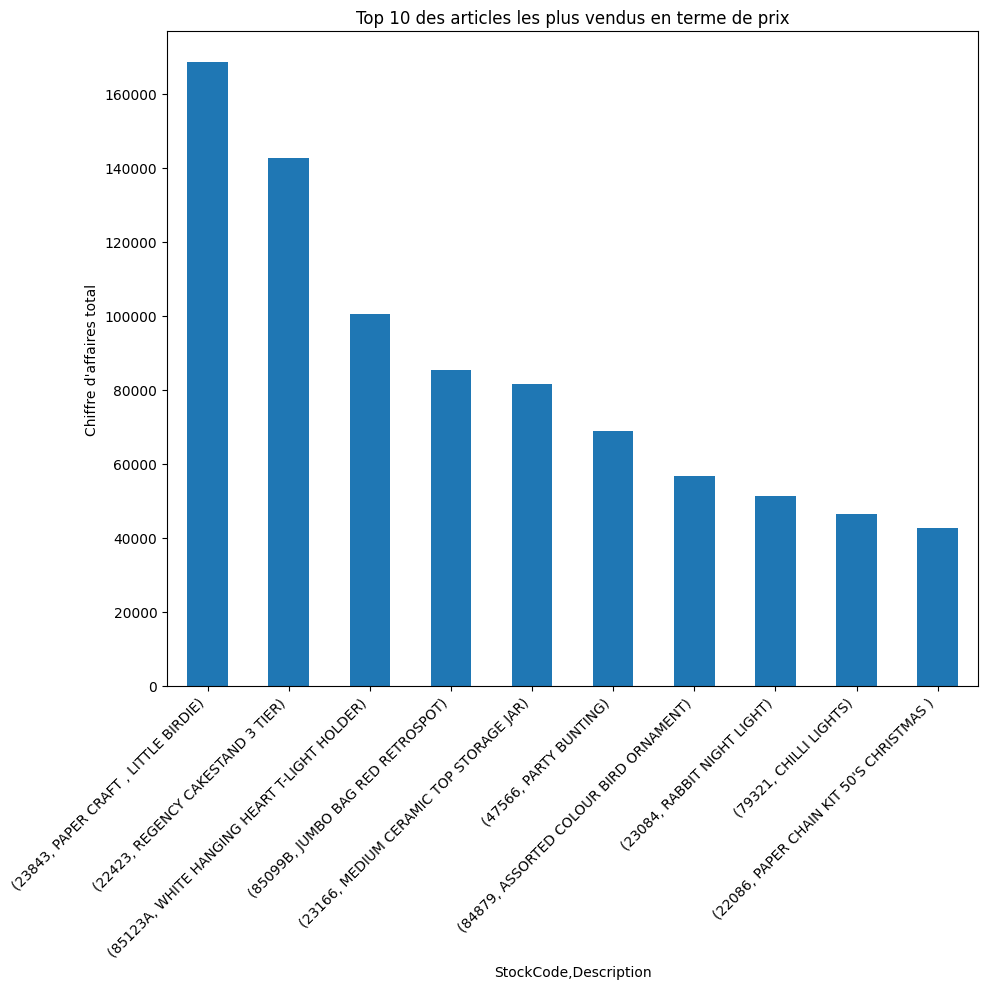

In [54]:
# Histogramme des 10 premiers articles les plus vendus en terme de prix

plt.figure(figsize=(10,10))
top10_stock_revenue.plot(kind='bar')
plt.ylabel("Chiffre d'affaires total")
plt.title("Top 10 des articles les plus vendus en terme de prix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Question 4.c. (5 points)
Sachant qu'il s'agit d'un détaillant britanique, son chiffre d'affaire à l'international est plus élevé que son chiffre d'affaire au Royaume-Uni ?

In [58]:
# TO DO
# On aggrège d'abord les revenus en fonction du pays.
total_by_country = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
uk_revenue = total_by_country.get('United Kingdom', 0.0)
international_revenue = total_by_country.sum() - uk_revenue

# On affiche les différents résultats.
print(f"Chiffre d'affaires UK : {uk_revenue:.2f}")
print(f"Chiffre d'affaires International : {international_revenue:.2f}")
print("International > UK ? :", international_revenue > uk_revenue)

Chiffre d'affaires UK : 7266027.23
Chiffre d'affaires International : 1495204.42
International > UK ? : False


Ainsi, le chiffre d'affaire à l'international est inférieur à celui au Royaume-Uni.

### 1.3. Prépararation de données - Représentation des données de transactions

La colonne "Description" de ce dataset contient plus de 3500 valeurs uniques. Pour notre analyse de règles d'association, nous voudrions regrouper les articles par catégorie.

Nous avons fourni le fichier ***group.csv*** qui contient pour chaque description d'article, le nom de son groupe d'article.

Nous fournissons le code ci-dessous qui permet de modifier le dataframe de telle sorte à obtenir une colonne supplémentaire dénommée "Group" comportant le nom de groupe des articles.

In [ ]:
import pandas as pd
import json
from pathlib import Path

grouped_path = Path("data/tp2/grouped.json")
if not grouped_path.exists():
    grouped_path = Path("../../data/tp2/grouped.json")

with grouped_path.open("r", encoding="utf-8") as f:
    familles_dict = json.load(f)

mapping = {}
for famille, objets in familles_dict.items():
    for obj in objets:
        mapping[obj.upper()] = famille

df["Description_clean"] = df["Description"].str.upper().str.strip()
df["Group"] = df["Description_clean"].map(mapping)
df = df.dropna(subset=["Group"])

print(df[["Description", "Group"]].head())

                           Description          Group
0   WHITE HANGING HEART T-LIGHT HOLDER     DECORATION
1                  WHITE METAL LANTERN  MISCELLANEOUS
2       CREAM CUPID HEARTS COAT HANGER     DECORATION
3  KNITTED UNION FLAG HOT WATER BOTTLE       TEXTILES
4       RED WOOLLY HOTTIE WHITE HEART.     DECORATION


#### Question 5 (5 points)
Pour l'analyse des règles d'association, on a besoin des paniers. Dans le dataset, chaque ligne correspond à un achat de produit. Plusieurs lignes peuvent avoir le même Invoice si un client a acheté plusieurs produits en une seule commande. On veut obtenir pour chaque panier, et par conséquent pour chaque InVoiceNo, tous les produits achetés ensemble dans la même facture.

A titre d'exemple, on aura :

| InvoiceNo | Panier               |
| ------- | -------------------------------- |
| 536365    | ['FOOD STORAGE', 'LIGHTING', 'DECORATION', 'TEXTILES', 'MISCELLANEOUS'] |
| 536367    | ['TOYS','CUSHIONS & COVERS', 'DECORATION', 'VINTAGE & RETRO', 'KITCHENWARE', 'MISCELLANEOUS', 'CRAFTS & SEWING']                 |





In [63]:
# TO DO : Nom du dataframe attendu (df_paniers)
# On veut pour chaque InvoiceNo la liste des groupes uniques associés
df_paniers = df.groupby('InvoiceNo')['Group'].apply(lambda x: list(x.unique())).reset_index()
df_paniers.columns = ['InvoiceNo', 'Panier']
print("Nombre de paniers :", df_paniers.shape[0])
df_paniers.head()

Nombre de paniers : 18327


,InvoiceNo,Panier
0,536365,"[DECORATION, MISCELLANEOUS, TEXTILES, FOOD STO..."
1,536366,[MISCELLANEOUS]
2,536367,"[DECORATION, TOYS, CRAFTS & SEWING, KITCHENWAR..."
3,536368,"[FOOD STORAGE, MISCELLANEOUS]"
4,536369,[BATHROOM & TOILETRIES]


In [64]:
# Décommentez la ligne suivante
df_paniers

,InvoiceNo,Panier
0,536365,"[DECORATION, MISCELLANEOUS, TEXTILES, FOOD STO..."
1,536366,[MISCELLANEOUS]
2,536367,"[DECORATION, TOYS, CRAFTS & SEWING, KITCHENWAR..."
3,536368,"[FOOD STORAGE, MISCELLANEOUS]"
4,536369,[BATHROOM & TOILETRIES]
...,...,...
18322,581583,"[LUNCH & DINNER, LIGHTING]"
18323,581584,"[DECORATION, LIGHTING]"
18324,581585,"[TEXTILES, DECORATION, LIGHTING, PETS & ANIMAL..."
18325,581586,"[DECORATION, VINTAGE & RETRO]"


#### Question 6 (5 points)
Effectuer l'encodage **One hot** sur l'ensemble des paniers avec la classe ***TransactionEncoder*** du module **_preprocessing_** de la librairie **_mlxtend._**. Le dataframe **df_encoded** doit contenir des colonnes qui représentent les noms des groupes de produits où chaque ligne de booléens représente un panier.  

In [66]:
from mlxtend.preprocessing import TransactionEncoder

transactions = df_paniers['Panier'].tolist()
te = TransactionEncoder()
te_bin = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_bin, columns=te.columns_)

# On affiche la dimension (nombre de lignes et de colonnes) du DataFrame binaire résultant.
# - Lignes : Le nombre initial de paniers.
# - Colonnes : Le nombre de groupes de produits uniques.
print("One-hot encodé : shape =", df_encoded.shape)

One-hot encodé : shape = (18327, 31)


In [67]:
# Décommentez la ligne suivante
df_encoded.head()

,ACCESSORIES & PURSES,BABY & CHILD,BAGS & SHOPPERS,BATHROOM & TOILETRIES,CANDLES,CARDS & WRAPPING,CHRISTMAS & HOLIDAYS,CHRISTMAS LIGHTS,CLOCKS & ALARMS,CRAFTS & SEWING,...,MISCELLANEOUS,PARTY & CELEBRATIONS,PETS & ANIMALS,SIGNS & WALL ART,STATIONERY,TABLEWARE,TEXTILES,TOYS,UMBRELLAS & RAINWEAR,VINTAGE & RETRO
0,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,True,False,False,False,False,False,False,True,False,True
3,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Cet encodage permet de passer à la partie suivante sur l'exécution de l'algorithme Apriori.

## 2. Analyse de règles d'association (75 points)

#### 2.1. Apriori


#### Question 7 (15 points)

L’algorithme **Apriori** permet de découvrir des règles d’association dans un ensemble de transactions. L’idée est de trouver quels articles sont souvent achetés ensemble, puis de formuler des règles du type : *si un client achète X, il achètera probablement Y*. Dans cette section de ce TP, nous allons appliquer Apriori pour extraire les itemsets fréquents et générer des règles d’association. Cet algorithme utilise une approche par niveaux pour générer des règles d'association, chaque niveau correspondant au nombre d'éléments appartenant à la conséquence de la règle.

En utilisant la librairie **_mlxtend_**,  on peut extraire les itemsets fréquents pour l'algorithme ***Apriori*** puis générer les règles d’association.

#### Question 7.1 (7.5 points)
Pour les valeurs de min_support allant de 0.1 à 0.5 avec une plage de 0.05, tracer une courbe indiquant le nombre de groupes d'articles fréquents pour chacune de ces valeurs de min_support.

Sur un autre graphe, tracer le temps d'exécution de l'algorithme Apriori pour chacune de ces valeurs de min_support.

Ensuite, interprétez ce que vous observer pour chacune de ces courbes.

In [72]:
import warnings
import jupyter_client

# Ignore la DeprecationWarning provenant spécifiquement du module 'jupyter_client'
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Nous avons rencontré des problèmes lors de l'exécution du code suivant par rapport à des avertissements de dépréciation au regard d'une fonction utilisé dans un package de jupyter_client. On a alors décidé de désactiver ces messages pour fluidifier la compréhension des résultats obtenus.

min_support=0.10 -> itemsets fréquents: 527, time: 0.165s
min_support=0.15 -> itemsets fréquents: 166, time: 0.061s
min_support=0.20 -> itemsets fréquents: 73, time: 0.026s
min_support=0.25 -> itemsets fréquents: 35, time: 0.010s
min_support=0.30 -> itemsets fréquents: 19, time: 0.007s
min_support=0.35 -> itemsets fréquents: 9, time: 0.004s
min_support=0.40 -> itemsets fréquents: 7, time: 0.004s
min_support=0.45 -> itemsets fréquents: 6, time: 0.003s
min_support=0.50 -> itemsets fréquents: 4, time: 0.004s


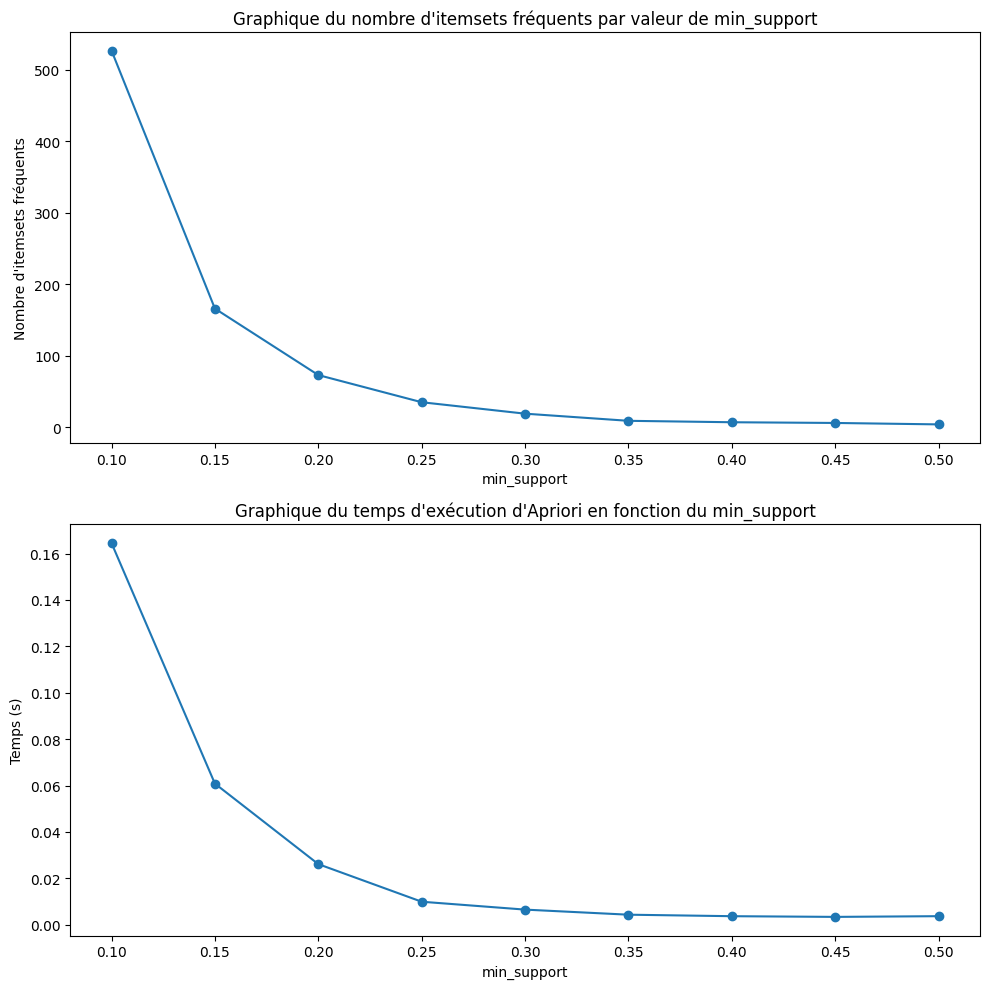

In [75]:
from mlxtend.frequent_patterns import apriori, association_rules
import time
import numpy as np

# TO DO
# On prépare l'exécution de l'algorithme Apriori pour chacune des valeurs de min_support.
# On prend des valeurs de min_support allant de 0.1 à 0.5 par pas de 0.05.
min_supports = np.arange(0.10, 0.51, 0.05)
counts = []
times = []

# C'est la boucle itérative de l'exécution de l'algorithme Apriori pour chacune des valeurs de min_support
# On stocke les valeurs temporelles au début et à la fin de chaque itération pour tracer le deuxième graphique.
for ms in min_supports:
    t0 = time.time()
    # apriori attend fraction support
    freq_items = apriori(df_encoded, min_support=ms, use_colnames=True)
    t1 = time.time()
    counts.append(freq_items.shape[0])
    times.append(t1 - t0)
    print(f"min_support={ms:.2f} -> itemsets fréquents: {freq_items.shape[0]}, time: {t1-t0:.3f}s")

# On trace la courbe indiquant le nombre de groupes d'articles fréquents pour chacune des valeurs de min_support.
plt.figure(figsize=(10,10))
plt.subplot(2,1,1)
plt.plot(min_supports, counts, marker='o')
plt.title("Graphique du nombre d'itemsets fréquents par valeur de min_support")
plt.xlabel("min_support")
plt.ylabel("Nombre d'itemsets fréquents")

# On trace le temps d'exécution de l'algorithme Apriori pour chacune des valeurs de min_support.
plt.subplot(2,1,2)
plt.plot(min_supports, times, marker='o')
plt.title("Graphique du temps d'exécution d'Apriori en fonction du min_support")
plt.xlabel("min_support")
plt.ylabel("Temps (s)")
plt.tight_layout()
plt.show()

On remarque ainsi que :

*   Plus le min_support augmente, moins il y a d'itemsets fréquents donc le temps d'exécution diminue
*   A faible min_support, beaucoup d'itemsets candidats => le temps d'exécution de l'algorithme est plus élevé.

Cette courbe décroissante est donc tout à fait logique. En effet, plus le seuil de min_support est élevé (plus on est exigeant), moins il y aura d'itemsets capables de satisfaire cette condition. Il faut donc maintenant sélectionner une valeur optimale de min_support qui est suffisament basse pour trouver un nombre de motifs avantageux mais aussi suffisament haute pour ne pas avoir un temps de calcul trop important.

#### Question 7.2 (7.5 points)
Fixer la valeur de ***min_support=0.3***. Pour les valeurs de min_confidence allant de 0.05 à 0.8 avec une plage de 0.05, tracer une courbe indiquant le nombre de règles pour chacune de de ces valeurs de min_confidence. Donner une interprétation du résultat obtenu.

min_conf=0.05 -> nb règles: 24
min_conf=0.10 -> nb règles: 24
min_conf=0.15 -> nb règles: 24
min_conf=0.20 -> nb règles: 24
min_conf=0.25 -> nb règles: 24
min_conf=0.30 -> nb règles: 24
min_conf=0.35 -> nb règles: 24
min_conf=0.40 -> nb règles: 24
min_conf=0.45 -> nb règles: 24
min_conf=0.50 -> nb règles: 22
min_conf=0.55 -> nb règles: 18
min_conf=0.60 -> nb règles: 16
min_conf=0.65 -> nb règles: 15
min_conf=0.70 -> nb règles: 15
min_conf=0.75 -> nb règles: 12
min_conf=0.80 -> nb règles: 5


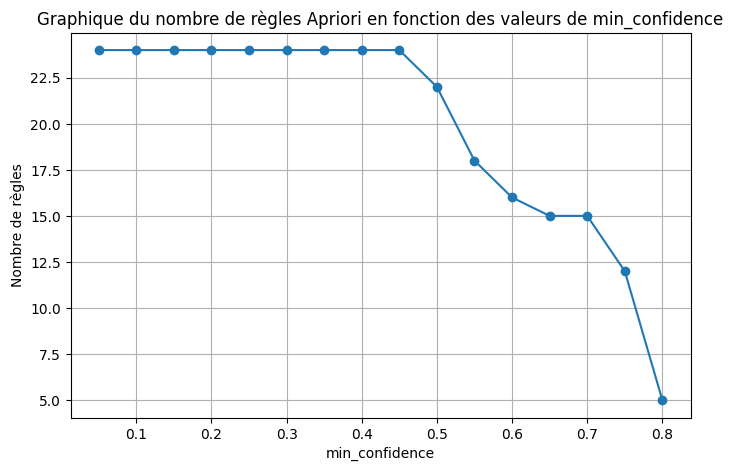

In [83]:
min_sup=0.3

#TO DO
freq_items_1 = apriori(df_encoded, min_support=min_sup, use_colnames=True)
min_conf = np.arange(0.05, 0.81, 0.05)
nbrules = []

# On boucle sur toutes les valeurs de min_confidence pour calculer le nombre de règles d'associations à partir des itemsets fréquents.
for mc in min_conf:
    rules = association_rules(freq_items_1, metric="confidence", min_threshold=mc)
    nbrules.append(rules.shape[0])
    print(f"min_conf={mc:.2f} -> nb règles: {rules.shape[0]}") # On affiche le nombre de règles par valeur de min_conf

# On trace la courbe indiquant le nombre de règles pour chacune des valeurs de min_confidence
plt.figure(figsize=(8,5))
plt.plot(min_conf, nbrules, marker='o')
plt.title(f"Graphique du nombre de règles Apriori en fonction des valeurs de min_confidence")
plt.xlabel("min_confidence")
plt.ylabel("Nombre de règles")
plt.grid(True)
plt.show()

On remarque ainsi que :

- En augmentant min_confidence, le nombre de règles diminue (seules les règles les plus fiables restent).
- À très faible confiance on a beaucoup de règles peu intéressantes ; à confiance trop élevée on peut n'en garder aucune.

Il s'agit alors encore d'une recherche de compromis.

### 2.2 FP-growth

Apriori fonctionne en générant systématiquement tous les candidats possibles et en vérifiant pour chacun leur support. Cette méthode devient rapidement **lente et coûteuse** lorsque le nombre d’items fréquents augmente. Des méthodes alternatives ont été développées pour surmonter les limites et améliorer l'efficacité de l'algorithme Apriori.

FP-growth, ou **Frequent Pattern Growth**, propose une approche plus efficace. Au lieu de générer tous les candidats, FP-growth utilise une structure de données compacte appelée **FP-tree** pour les transactions fréquentes. L’idée est la suivante : représenter les transactions sous forme d’arbre, où les chemins partagés entre transactions sont fusionnés, ce qui réduit considérablement le nombre d’opérations nécessaires.

Pour construire un FP-tree, on commence par compter la **fréquence de chaque item** dans l’ensemble des transactions et on élimine les items peu fréquents (ceux dont le support est inférieur à un seuil minimum). Les items restants sont ensuite **triés par ordre décroissant de fréquence**. Chaque transaction devient un chemin dans l’arbre, en suivant cet ordre. Les transactions partageant des items fréquents communs se superposent dans l’arbre, ce qui permet de représenter toutes les transactions de manière très compacte.

Une fois l’arbre construit, l’extraction des itemsets fréquents se fait en parcourant l’arbre à partir des items les moins fréquents (en bas de la table de liens ou "header table") et en combinant les chemins pour générer des patterns fréquents. Contrairement à Apriori, FP-growth **ne génère jamais tous les candidats possibles** : il utilise la structure de l’arbre pour extraire directement les itemsets fréquents, ce qui rend la méthode beaucoup plus rapide et efficace, surtout pour les datasets volumineux ou contenant de nombreux items fréquents.


Dans cette section du TP, vous allez implémenter FP-growth, sans utiliser des librairies spécialisées pour les règles d’association.

#### 2.2.1 Construction d’un FP-tree
Dans l’algorithme **FP-Growth**, l’étape clé consiste à construire un **FP-tree (Frequent Pattern Tree)**.  Cet arbre est construit en mappant chaque transaction sur un chemin dans l'arbre. Comme différentes transactions peuvent avoir plusieurs articles en commun, leurs chemins peuvent se chevaucher. Ainsi, plus les données se chevauchent, plus on peut obtenir une compression importante.

#### Question 8 (20 points)

On vous demande de compléter la fonction ***build_fp_tree*** qui :  

1. Compte la fréquence de chaque item et calcule son support.  
2. Élimine les items dont le support est inférieur à `min_support`.  
3. Trie les items de chaque panier par ordre décroissant de support.  
4. Construit un **arbre orienté (FP-tree)** où :  
   - La racine est un nœud `"root"`. Chaque panier trié commence toujours par le nœud `"root"`.
   - Chaque chemin correspond à un panier filtré et trié.  
   - Chaque nœud contient un compteur indiquant le nombre de paniers dans lesquels il apparaît.  


In [84]:

def build_fp_tree(transactions, min_support):

    # 1
    # TO DO : On compte la fréquence de chaque item et calcule son support.
    item_counts = {}
    for panier in transactions:
        for item in panier:
            item_counts[item] = item_counts.get(item, 0) + 1

    # On calcule le support total
    num_transactions = len(transactions)
    item_supports = {item: count / num_transactions for item, count in item_counts.items()}

    # 2
    # TO DO : On élimine les items dont le support est inférieur à min_support.
    frequent_items = {item for item, sup in item_supports.items() if sup >= min_support}

    # 3
    # TO DO : On trie les items de chaque panier par ordre décroissant de support.
    filtered_transactions = []
    for panier in transactions:
        # On garde uniquement les items fréquents
        filtered = [item for item in panier if item in frequent_items]
        # Tri décroissant du support
        filtered.sort(key=lambda i: (-item_supports[i], i))
        if filtered:
            filtered_transactions.append(filtered)

    # 4
    # TO DO : On construit un arbre orienté (FP-tree)
    tree = {'root': {'count': 0, 'children': {}}}  # structure de base

    for panier in filtered_transactions:
        current_node = tree['root']
        current_node['count'] += 1
        for item in panier:
            # Si le nœud n’existe pas encore, on le crée
            if item not in current_node['children']:
                current_node['children'][item] = {'count': 0, 'children': {}}
            # On avance dans l’arbre
            current_node = current_node['children'][item]
            current_node['count'] += 1

    return tree

Utilisez la fonction test_fp_tree pour vérifier votre implémentation de la fonction précédente sur. Afficher le graphe obtenu en tenant compte de votre structure de données. Un type particulier d'affichage n'est pas exigé.  


Première version de la fonction test_fp_tree avec un affichage peu clair

In [86]:
def test_fp_tree():
    transactions = [['a', 'b', 'c'],['a','b','c','d'], ['b','c','e'],  ['a','c','d','e'], ['d','e']]

    graph = build_fp_tree(transactions, 0.0)

    # TO DO
    # Affichage structuré de l’arbre
    import pprint
    print("===== FP-TREE CONSTRUIT =====")
    pprint.pprint(graph)

    # Vérification simple du contenu attendu
    assert 'root' in graph, "La racine 'root' doit exister."
    assert 'children' in graph['root'], "La racine doit avoir un champ 'children'."
    print("\n Test basique passé : structure de l’arbre valide.")

test_fp_tree()

===== FP-TREE CONSTRUIT =====
{'root': {'children': {'c': {'children': {'a': {'children': {'b': {'children': {'d': {'children': {},
                                                                                      'count': 1}},
                                                                   'count': 2},
                                                             'd': {'children': {'e': {'children': {},
                                                                                      'count': 1}},
                                                                   'count': 1}},
                                                'count': 3},
                                          'b': {'children': {'e': {'children': {},
                                                                   'count': 1}},
                                                'count': 1}},
                             'count': 4},
                       'd': {'children': {'e': {'children': {}, 'count': 1}}

Deuxième version de la fonction test_fp_tree avec un affichage plus clair grâce au package networkx et la mise en place d'un graphe orienté.

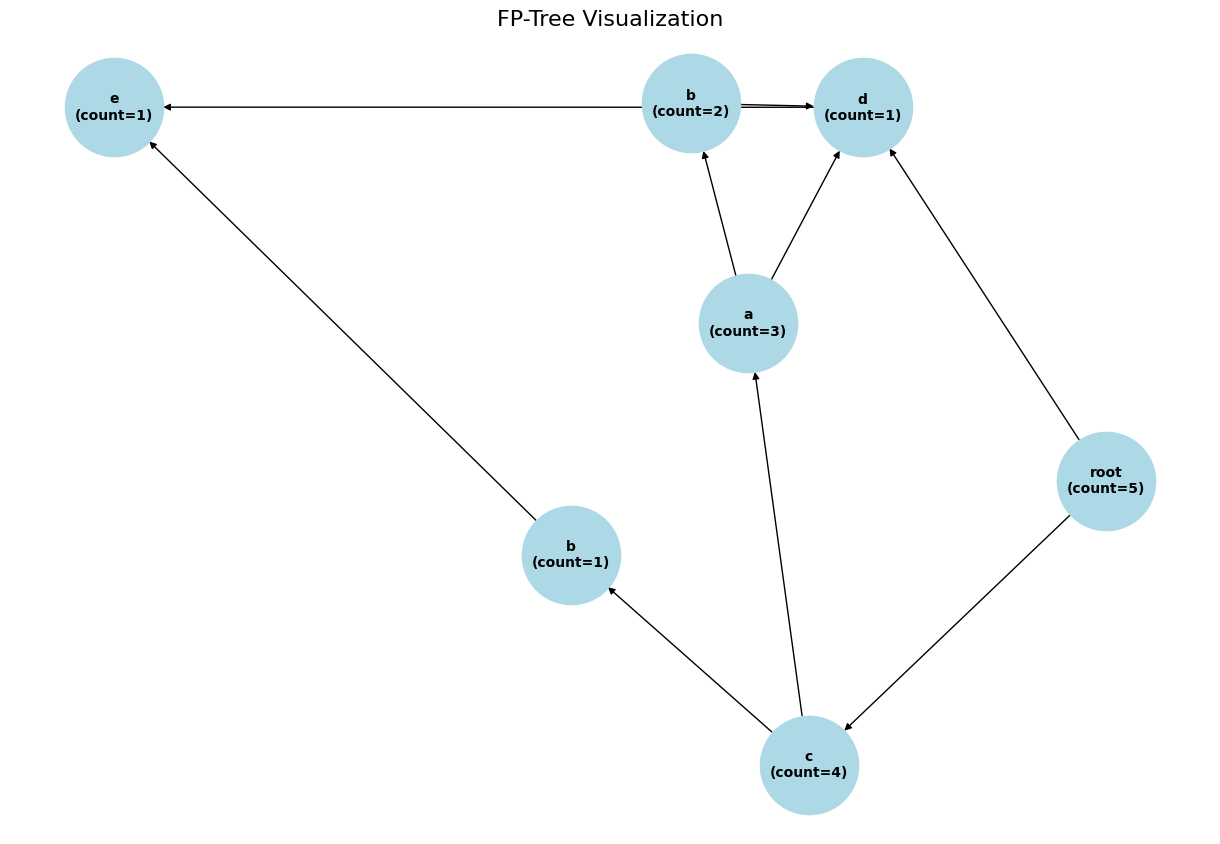

In [92]:
import networkx as nx

def test_fp_tree():
    transactions = [['a', 'b', 'c'],['a','b','c','d'], ['b','c','e'],  ['a','c','d','e'], ['d','e']]

    tree = build_fp_tree(transactions, 0.0)

    # Crée un graphe orienté
    G = nx.DiGraph()

    # Fonction récursive pour ajouter les nœuds/liaisons dans le graphe
    def add_edges(node, parent_name):
        for item, data in node.items():
            node_name = f"{item}\n(count={data['count']})"
            G.add_node(node_name)
            if parent_name is not None:
                G.add_edge(parent_name, node_name)
            add_edges(data["children"], node_name)

    # Construction du graphe
    add_edges({'root': tree['root']}, None)

    # Mise en page hiérarchique
    pos = nx.spring_layout(G, seed=42, k=0.5)
    plt.figure(figsize=(12, 8))

    # Dessin du graphe
    nx.draw(
        G, pos,
        with_labels=True,
        node_color="lightblue",
        node_size=5000,
        font_size=10,
        font_weight="bold",
        arrows=True
    )

    plt.title("FP-Tree Visualization", fontsize=16)
    plt.show()

test_fp_tree()

#### 2.2.2  Extraction des itemsets fréquents dans l'algirithme FP-Growth.
####  Question 9 (10 points)

Dans cette section du TP, nous allons exploiter le précédent **FP-tree** déjà construit.  
Le FP-tree contient des items **triés par fréquence décroissante**, et chaque nœud a un attribut `count` indiquant le nombre de transactions passant par ce nœud.

Votre tâche est d’écrire une fonction `mine_tree(G, min_support)` qui :

1. Explore tous les chemins du FP-tree à partir des articles les moins fréquents.
2. Pour chaque chemin, construit les **itemsets associés** et calcule leur **support**.
3. Ne conserve que les itemsets dont le support est supérieur ou égal à `min_support`.


In [ ]:

def mine_tree(tree, min_support):
    # TO DO
    return patterns


#### Question 10 (10 points)

Pour analyser les patterns obtenus, veuillez compléter la fonction suivante qui permet d'afficher un dataframe avec les colonnes ***antecedents***, ***consequents***, et les métriques **support**, **confidence** et **lift**. Le dataframe ***df_rules*** doit contenir les colonnes :

| antecedents | consequents               | support	| confidence |lift |
| ------- | ---------------------- | ----------------| --------------- |  --------------- |

In [ ]:
# TO DO
from itertools import combinations


def patterns_to_df_with_metrics(patterns, transactions):
    # TO DO
    return df

#### Question 11 (5 points)

Pour une même valeur valeur de min_support et une même valeur de min_confidence, générer les règles avec les deux méthodes Apriori et FP-Growth puis donner une intéprétation comparative des résultats issus des deux algorithmes? L'affichage des règles générées par l'algorithme FP-Growth se fera avec la fonction ***patterns_to_df_with_metrics***.

Jusifier brièvement votre choix des valeurs de min_support et min_confidence.

In [ ]:
# TO DO

#### Question-conclusion (5 points)
Après la fouille des données que vous avez faites, quelles informations auriez-vous donner à ce détaillant ?  

#Réponse attendue : minimum 3 phrases , maximum 5 phrases